Step 1: Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.chart import BarChart, Reference
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


Step 2: Upload & Load Data

In [9]:
from google.colab import files
uploaded = files.upload()  # Upload your train.csv here

df = pd.read_csv('/content/drive/MyDrive/superstore sales/train.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['Quarter']    = df['Order Date'].dt.quarter
df['Days_to_Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

print(f'Loaded: {df.shape[0]:,} rows')
df.head(3)

Loaded: 9,800 rows


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Quarter,Days_to_Ship
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2017,11,4,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,2017,11,4,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2017,6,2,4


Step 3: KPI Summary (SQL-style aggregation)

In [10]:
# --- Top-level KPIs ---
total_sales    = df['Sales'].sum()
total_orders   = df['Order ID'].nunique()
avg_order_val  = total_sales / total_orders
best_region    = df.groupby('Region')['Sales'].sum().idxmax()
best_category  = df.groupby('Category')['Sales'].sum().idxmax()

print('=' * 40)
print('       BUSINESS KPI SUMMARY')
print('=' * 40)
print(f'  Total Revenue      : ${total_sales:>12,.2f}')
print(f'  Total Orders       : {total_orders:>12,}')
print(f'  Avg Order Value    : ${avg_order_val:>12,.2f}')
print(f'  Best Region        : {best_region:>12}')
print(f'  Best Category      : {best_category:>12}')
print('=' * 40)

       BUSINESS KPI SUMMARY
  Total Revenue      : $2,261,536.78
  Total Orders       :        4,922
  Avg Order Value    : $      459.48
  Best Region        :         West
  Best Category      :   Technology


Step 4: Regional Performance Breakdown

In [11]:
# Regional summary table
region_summary = df.groupby('Region').agg(
    Total_Sales    = ('Sales', 'sum'),
    Num_Orders     = ('Order ID', 'nunique'),
    Avg_Order_Val  = ('Sales', 'mean'),
    Avg_Ship_Days  = ('Days_to_Ship', 'mean')
).round(2).sort_values('Total_Sales', ascending=False).reset_index()

region_summary['Sales_Share_%'] = (
    region_summary['Total_Sales'] / region_summary['Total_Sales'].sum() * 100
).round(1)

print('=== REGIONAL PERFORMANCE ===')
print(region_summary.to_string(index=False))

=== REGIONAL PERFORMANCE ===
 Region  Total_Sales  Num_Orders  Avg_Order_Val  Avg_Ship_Days  Sales_Share_%
   West    710219.68        1587         226.18           3.93           31.4
   East    669518.73        1369         240.40           3.91           29.6
Central    492646.91        1156         216.36           4.07           21.8
  South    389151.46         810         243.52           3.96           17.2


In [12]:
# Category breakdown per region
region_category = df.groupby(['Region', 'Category'])['Sales'].sum().unstack().round(2)
region_category['TOTAL'] = region_category.sum(axis=1)
region_category = region_category.sort_values('TOTAL', ascending=False)

print('=== SALES BY REGION & CATEGORY ===')
print(region_category.to_string())

=== SALES BY REGION & CATEGORY ===
Category  Furniture  Office Supplies  Technology      TOTAL
Region                                                     
West      245348.25        217466.51   247404.93  710219.69
East      206461.39        199940.81   263116.53  669518.73
Central   160317.46        163590.24   168739.21  492646.91
South     116531.48        124424.77   148195.21  389151.46


Step 5: Visualisations

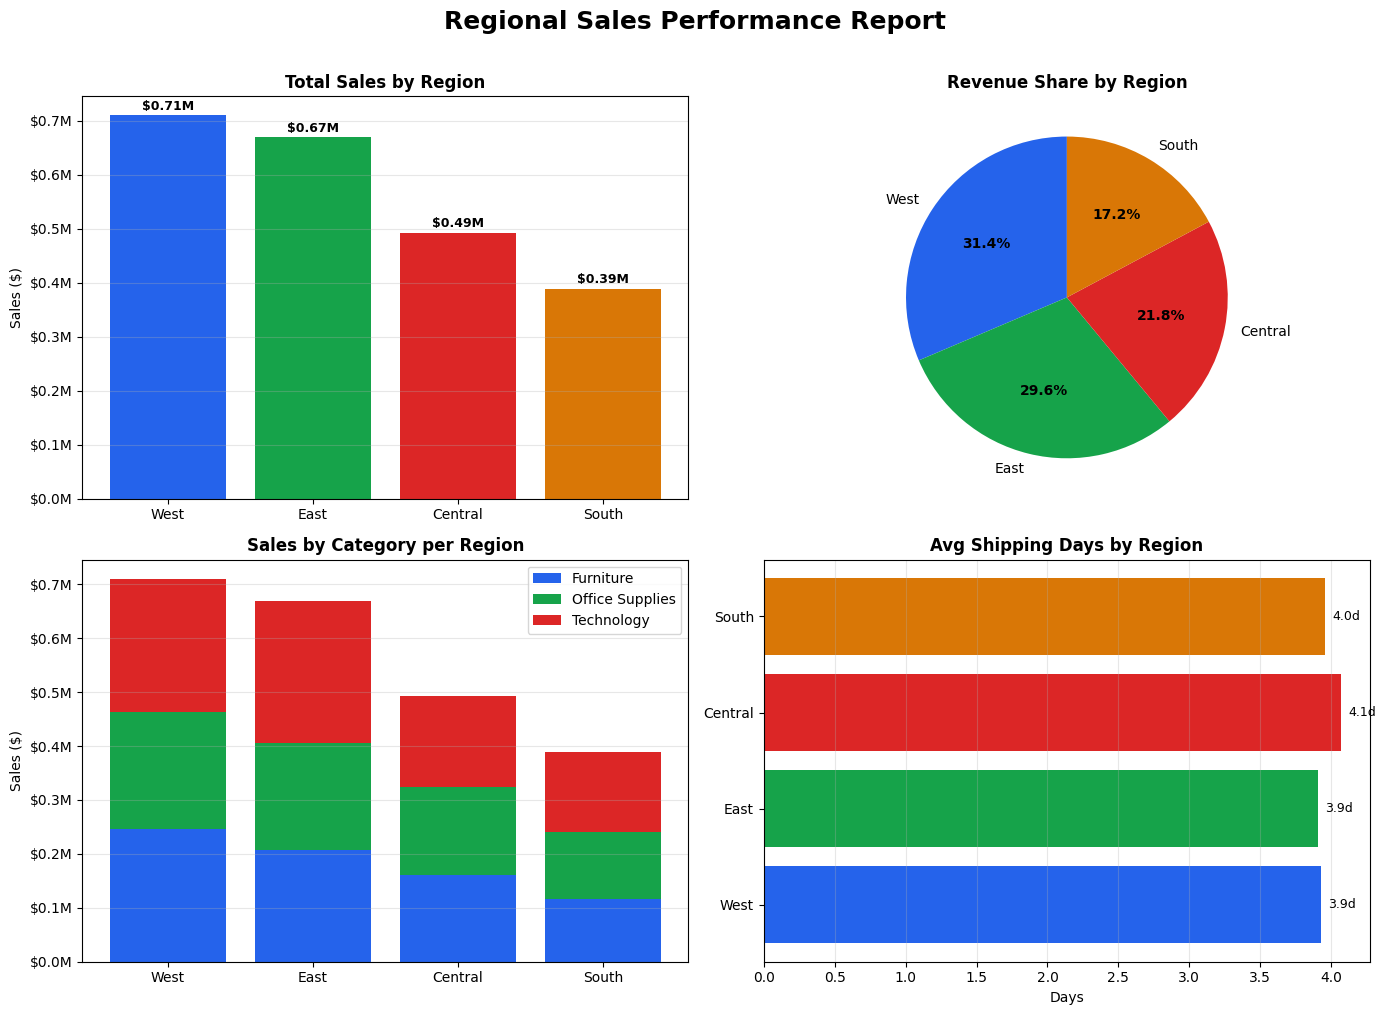

Saved as regional_performance.png


In [13]:
colors = ['#2563EB', '#16A34A', '#DC2626', '#D97706']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Regional Sales Performance Report', fontsize=18, fontweight='bold', y=1.01)

# 1. Total Sales by Region
ax = axes[0, 0]
bars = ax.bar(region_summary['Region'], region_summary['Total_Sales'], color=colors)
ax.set_title('Total Sales by Region', fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for bar, val in zip(bars, region_summary['Total_Sales']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'${val/1e6:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 2. Sales Share (Pie)
ax = axes[0, 1]
wedges, texts, autotexts = ax.pie(
    region_summary['Sales_Share_%'],
    labels=region_summary['Region'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title('Revenue Share by Region', fontweight='bold')

# 3. Sales by Category per Region (stacked bar)
ax = axes[1, 0]
cat_cols = ['Furniture', 'Office Supplies', 'Technology']
cat_colors = ['#2563EB', '#16A34A', '#DC2626']
bottom = np.zeros(len(region_category))
for cat, col in zip(cat_cols, cat_colors):
    vals = region_category[cat].values
    ax.bar(region_category.index, vals, bottom=bottom, label=cat, color=col)
    bottom += vals
ax.set_title('Sales by Category per Region', fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

# 4. Avg Shipping Days by Region
ax = axes[1, 1]
ax.barh(region_summary['Region'], region_summary['Avg_Ship_Days'], color=colors)
ax.set_title('Avg Shipping Days by Region', fontweight='bold')
ax.set_xlabel('Days')
for i, val in enumerate(region_summary['Avg_Ship_Days']):
    ax.text(val + 0.05, i, f'{val:.1f}d', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('regional_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as regional_performance.png')

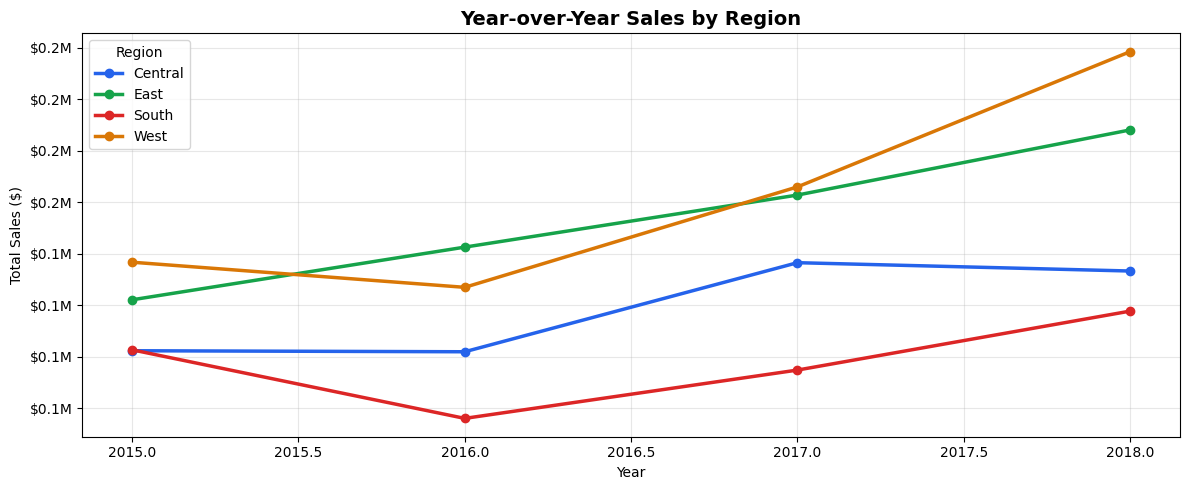

 Saved as yoy_region_trend.png


In [16]:
# Year-over-year sales trend by region
yearly_region = df.groupby(['Year', 'Region'])['Sales'].sum().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
for i, region in enumerate(yearly_region.columns):
    ax.plot(yearly_region.index, yearly_region[region],
            marker='o', linewidth=2.5, label=region, color=colors[i])

ax.set_title('Year-over-Year Sales by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend(title='Region')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('yoy_region_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved as yoy_region_trend.png')

Step 6: Export Professional Excel Report

In [18]:
wb = Workbook()

# --- Colour palette ---
BLUE   = '2563EB'
WHITE  = 'FFFFFF'
LGREY  = 'F3F4F6'
DGREY  = '374151'

header_font  = Font(bold=True, color=WHITE, size=11)
header_fill  = PatternFill('solid', fgColor=BLUE)
title_font   = Font(bold=True, size=14, color=DGREY)
center       = Alignment(horizontal='center', vertical='center')
thin         = Side(style='thin', color='D1D5DB')
border       = Border(left=thin, right=thin, top=thin, bottom=thin)

def style_header_row(ws, row, ncols):
    for col in range(1, ncols + 1):
        cell = ws.cell(row=row, column=col)
        cell.font   = header_font
        cell.fill   = header_fill
        cell.alignment = center
        cell.border = border

def style_data_row(ws, row, ncols, shade=False):
    for col in range(1, ncols + 1):
        cell = ws.cell(row=row, column=col)
        cell.alignment = center
        cell.border    = border
        if shade:
            cell.fill = PatternFill('solid', fgColor=LGREY)

# ===================== SHEET 1: EXECUTIVE SUMMARY =====================
ws1 = wb.active
ws1.title = 'Executive Summary'
ws1.column_dimensions['A'].width = 28
ws1.column_dimensions['B'].width = 22

ws1['A1'] = 'Regional Sales Performance Report'
ws1['A1'].font = Font(bold=True, size=16, color=BLUE)
ws1.merge_cells('A1:B1')
ws1['A1'].alignment = center

ws1['A2'] = 'Superstore Dataset Analysis'
ws1['A2'].font = Font(italic=True, size=11, color=DGREY)
ws1.merge_cells('A2:B2')
ws1['A2'].alignment = center

kpis = [
    ('KPI', 'Value'),
    ('Total Revenue', f'${total_sales:,.2f}'),
    ('Total Orders', f'{total_orders:,}'),
    ('Avg Order Value', f'${avg_order_val:,.2f}'),
    ('Best Performing Region', best_region),
    ('Best Performing Category', best_category),
    ('Date Range', f'{df["Order Date"].min().date()} to {df["Order Date"].max().date()}'),
    ('Total Products Sold', f'{df["Product ID"].nunique():,}'),
]

for i, (k, v) in enumerate(kpis, start=4):
    ws1.cell(i, 1, k)
    ws1.cell(i, 2, v)
    shade = (i % 2 == 0)
    if i == 4:
        style_header_row(ws1, i, 2)
    else:
        style_data_row(ws1, i, 2, shade)

# ===================== SHEET 2: REGIONAL BREAKDOWN =====================
ws2 = wb.create_sheet('Regional Breakdown')
ws2['A1'] = 'Sales Performance by Region'
ws2['A1'].font = title_font
ws2.merge_cells('A1:F1')

headers = ['Region', 'Total Sales ($)', 'No. Orders', 'Avg Order Value ($)', 'Avg Ship Days', 'Sales Share (%)']
col_widths = [14, 18, 14, 22, 16, 16]
for j, (h, w) in enumerate(zip(headers, col_widths), 1):
    ws2.cell(3, j, h)
    ws2.column_dimensions[get_column_letter(j)].width = w
style_header_row(ws2, 3, len(headers))

for i, row in region_summary.iterrows():
    r = i + 4
    ws2.cell(r, 1, row['Region'])
    ws2.cell(r, 2, round(row['Total_Sales'], 2))
    ws2.cell(r, 3, row['Num_Orders'])
    ws2.cell(r, 4, round(row['Avg_Order_Val'], 2))
    ws2.cell(r, 5, round(row['Avg_Ship_Days'], 2))
    ws2.cell(r, 6, row['Sales_Share_%'])
    style_data_row(ws2, r, len(headers), shade=(i % 2 == 0))

# ===================== SHEET 3: CATEGORY ANALYSIS =====================
ws3 = wb.create_sheet('Category Analysis')
ws3['A1'] = 'Sales by Category and Sub-Category'
ws3['A1'].font = title_font
ws3.merge_cells('A1:D1')

cat_detail = df.groupby(['Category', 'Sub-Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Num_Orders=('Order ID', 'nunique')
).round(2).reset_index().sort_values('Total_Sales', ascending=False)

cat_headers = ['Category', 'Sub-Category', 'Total Sales ($)', 'No. Orders']
cat_widths  = [18, 20, 18, 14]
for j, (h, w) in enumerate(zip(cat_headers, cat_widths), 1):
    ws3.cell(3, j, h)
    ws3.column_dimensions[get_column_letter(j)].width = w
style_header_row(ws3, 3, len(cat_headers))

for i, row in cat_detail.iterrows():
    r = i + 4
    ws3.cell(r, 1, row['Category'])
    ws3.cell(r, 2, row['Sub-Category'])
    ws3.cell(r, 3, row['Total_Sales'])
    ws3.cell(r, 4, row['Num_Orders'])
    style_data_row(ws3, r, len(cat_headers), shade=(i % 2 == 0))

# ===================== SHEET 4: YEARLY TREND =====================
ws4 = wb.create_sheet('Yearly Trend')
ws4['A1'] = 'Year-over-Year Sales by Region'
ws4['A1'].font = title_font
ws4.merge_cells('A1:F1')

yearly_region_reset = yearly_region.reset_index()
yoy_headers = ['Year'] + list(yearly_region.columns) + ['TOTAL']
for j, h in enumerate(yoy_headers, 1):
    ws4.cell(3, j, h)
    ws4.column_dimensions[get_column_letter(j)].width = 16
style_header_row(ws4, 3, len(yoy_headers))

for i, row in yearly_region_reset.iterrows():
    r = i + 4
    ws4.cell(r, 1, int(row['Year']))
    total = 0
    for j, col in enumerate(yearly_region.columns, 2):
        val = round(row[col], 2)
        ws4.cell(r, j, val)
        total += val
    ws4.cell(r, len(yoy_headers), round(total, 2))
    style_data_row(ws4, r, len(yoy_headers), shade=(i % 2 == 0))

# Save
output_path = 'Regional_Sales_Report.xlsx'
wb.save(output_path)
print(f'Excel report saved: {output_path}')

# Download it
files.download(output_path)
print('Download started!')

Excel report saved: Regional_Sales_Report.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!
